# Feature Engineering for Crypto Price Prediction

This notebook focuses on creating and analyzing machine learning features for Bitcoin price prediction.

## Objectives
- Create technical and time-series features
- Prepare data for ML models
- Analyze feature relationships
- Build preprocessing foundation for training pipeline

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

Load Bitcoin historical price dataset for feature engineering.

In [52]:
df = pd.read_csv("btc_data.csv")

df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
1,Date,NaN,NaN,NaN,NaN,NaN
2,2018-01-01,13657.2001953125,14112.2001953125,13154.7001953125,14112.2001953125,10291200000
3,2018-01-02,14982.099609375,15444.599609375,13163.599609375,13625.0,16846600192
4,2018-01-03,15201.0,15572.7998046875,14844.5,14978.2001953125,16871900160


# Dataset Information

Check dataset structure, columns, and missing values.

In [53]:
print(df.shape)

df.info()

(2924, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2924 entries, 0 to 2923
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   2924 non-null   object
 1   Close   2923 non-null   object
 2   High    2923 non-null   object
 3   Low     2923 non-null   object
 4   Open    2923 non-null   object
 5   Volume  2923 non-null   object
dtypes: object(6)
memory usage: 137.2+ KB


In [54]:
df.isnull().sum()

,0
Price,0
Close,1
High,1
Low,1
Open,1
Volume,1


In [55]:
df = df.rename(columns={'Price': 'Date'})
df = df.iloc[2:].reset_index(drop=True)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])

In [56]:
df['MA7'] = df['Close'].rolling(window=7).mean()

df['MA30'] = df['Close'].rolling(window=30).mean()

df[['Close', 'MA7', 'MA30']].head(10)

,Close,MA7,MA30
0,13657.2001953125,NaN,NaN
1,14982.099609375,NaN,NaN
2,15201.0,NaN,NaN
3,15599.2001953125,NaN,NaN
4,17429.5,NaN,NaN
5,17527.0,NaN,NaN
6,16477.599609375,15839.085658,NaN
7,15170.099609375,16055.214146,NaN
8,14595.400390625,15999.971401,NaN
9,14973.2998046875,15967.442801,NaN


In [57]:
df['Close'] = pd.to_numeric(df['Close'])
df['Returns'] = df['Close'].pct_change()

df[['Close', 'Returns']].head()

,Close,Returns
0,13657.200195,NaN
1,14982.099609,0.097011
2,15201.000000,0.014611
3,15599.200195,0.026196
4,17429.500000,0.117333


In [58]:
df['Lag1'] = df['Close'].shift(1)

df['Lag2'] = df['Close'].shift(2)

df['Lag3'] = df['Close'].shift(3)

df[['Close', 'Lag1', 'Lag2', 'Lag3']].head()

,Close,Lag1,Lag2,Lag3
0,13657.200195,NaN,NaN,NaN
1,14982.099609,13657.200195,NaN,NaN
2,15201.000000,14982.099609,13657.200195,NaN
3,15599.200195,15201.000000,14982.099609,13657.200195
4,17429.500000,15599.200195,15201.000000,14982.099609


# Handle Missing Values

Rolling windows and lag features create missing values at the beginning of the dataset.

In [59]:
df.dropna(inplace=True)

df.isnull().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0
MA7,0
MA30,0
Returns,0
Lag1,0


# Correlation Analysis

Analyze relationships between engineered features and target variables.

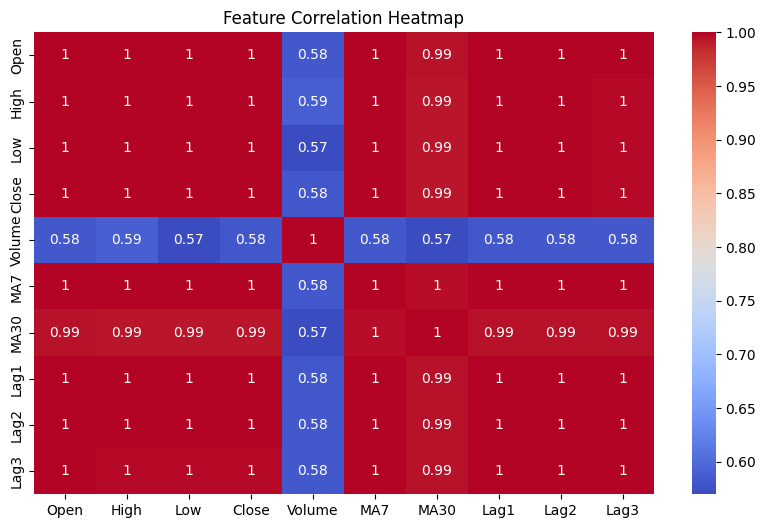

In [60]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df[['Open','High','Low','Close','Volume','MA7','MA30','Lag1','Lag2','Lag3']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

# Moving Average Visualization

Visualize moving averages against Bitcoin closing prices.

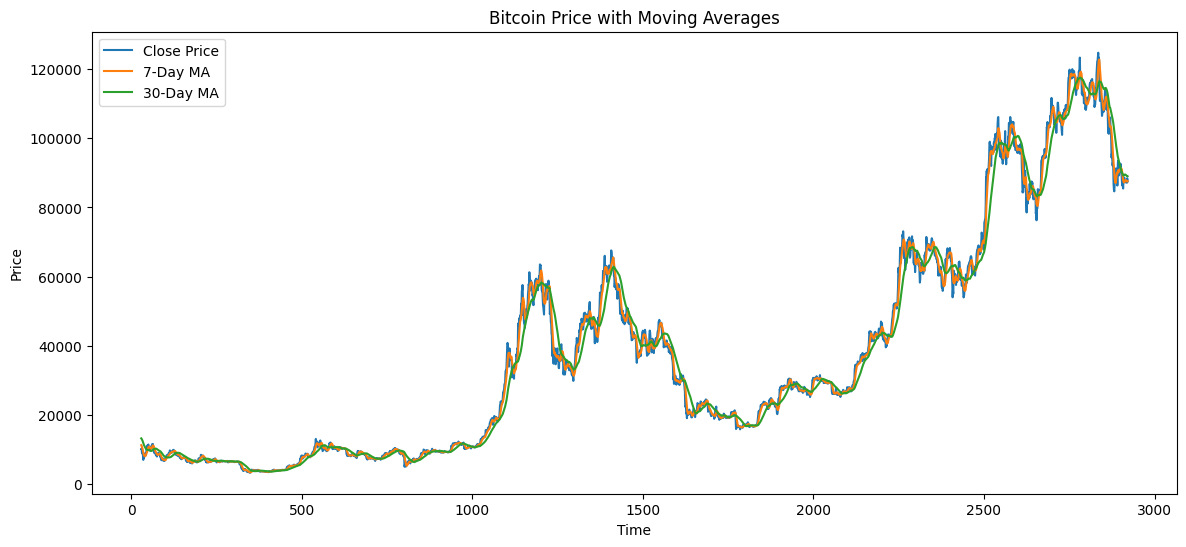

In [61]:
plt.figure(figsize=(14,6))

plt.plot(df['Close'], label='Close Price')

plt.plot(df['MA7'], label='7-Day MA')

plt.plot(df['MA30'], label='30-Day MA')

plt.legend()

plt.title("Bitcoin Price with Moving Averages")

plt.xlabel("Time")

plt.ylabel("Price")

plt.show()

# Final Feature Dataset

Prepare final feature columns for machine learning models.

In [62]:
features = [
    'Open',
    'High',
    'Low',
    'Volume',
    'MA7',
    'MA30',
    'Lag1',
    'Lag2',
    'Lag3'
]

target = 'Close'

X = df[features]

y = df[target]

print("Feature Shape:", X.shape)

print("Target Shape:", y.shape)

Feature Shape: (2893, 9)
Target Shape: (2893,)


In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[features] = scaler.fit_transform(df[features])

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Final Observations

## Key Insights
- Moving averages help smooth market trends
- Lag features provide historical context for predictions
- Volume and price features show strong relationships
- Time-series ordering is critical for model training
